In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.linalg import lu, svd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

In [7]:
df = pd.read_csv('Data\\student_performance.csv')
print('Dataset Shape:', df.shape)
df.head()

Dataset Shape: (20, 9)


,Student_ID,Name,Math,Physics,Chemistry,Biology,Computer_Science,English,Statistics
0,S001,Alice Johnson,92,88,85,79,95,74,90
1,S002,Bob Smith,78,72,68,85,80,88,75
2,S003,Carol White,85,90,88,76,92,70,88
3,S004,David Brown,60,55,62,70,65,80,58
4,S005,Eva Martinez,95,93,91,88,97,72,94


# Part A: Vector & Matrix Fundamentals


---
## 1: Represent Each Student's Scores as a Vector

Each student's subject scores across **Math, Physics, Chemistry, Biology, Computer_Science, English, Statistics** form a **7-dimensional vector**.

In [8]:
# Extract score columns (features)
subjects = ['Math', 'Physics', 'Chemistry', 'Biology', 'Computer_Science', 'English', 'Statistics']

# Score matrix: each ROW is one student's score vector
score_matrix = df[subjects].values  # shape: (20, 7)

print('Score Matrix Shape:', score_matrix.shape)
print('\n--- First 5 Student Vectors ---')
for i in range(5):
    print(f"{df['Name'][i]}: {score_matrix[i]}")

Score Matrix Shape: (20, 7)

--- First 5 Student Vectors ---
Alice Johnson: [92 88 85 79 95 74 90]
Bob Smith: [78 72 68 85 80 88 75]
Carol White: [85 90 88 76 92 70 88]
David Brown: [60 55 62 70 65 80 58]
Eva Martinez: [95 93 91 88 97 72 94]


In [9]:
# Represent individual students as named vectors
student_vectors = {}
for i, row in df.iterrows():
    student_vectors[row['Name']] = np.array(row[subjects].values, dtype=float)

# Example: Alice Johnson's vector
v_alice = student_vectors['Alice Johnson']
v_bob   = student_vectors['Bob Smith']

print('Alice Johnson vector:', v_alice)
print('Bob Smith vector    :', v_bob)

Alice Johnson vector: [92. 88. 85. 79. 95. 74. 90.]
Bob Smith vector    : [78. 72. 68. 85. 80. 88. 75.]


---
## 2: Compute Norms, Dot Product, Angle & Cross Product

### 2a. Norm-1 and Norm-2 of Vectors

- **Norm-1 (Manhattan norm):** $\|\mathbf{v}\|_1 = \sum |v_i|$
- **Norm-2 (Euclidean norm):** $\|\mathbf{v}\|_2 = \sqrt{\sum v_i^2}$

In [10]:
# Compute Norm-1 and Norm-2 for Alice and Bob
norm1_alice = np.linalg.norm(v_alice, ord=1)
norm2_alice = np.linalg.norm(v_alice, ord=2)

norm1_bob = np.linalg.norm(v_bob, ord=1)
norm2_bob = np.linalg.norm(v_bob, ord=2)

print('=== Alice Johnson ===')
print(f'  Norm-1 (L1): {norm1_alice:.4f}')
print(f'  Norm-2 (L2): {norm2_alice:.4f}')

print('\n=== Bob Smith ===')
print(f'  Norm-1 (L1): {norm1_bob:.4f}')
print(f'  Norm-2 (L2): {norm2_bob:.4f}')

# Compute norms for ALL students
print('\n--- All Students: Norm-1 and Norm-2 ---')
norm_data = []
for name, vec in student_vectors.items():
    norm_data.append({'Name': name,
                      'Norm-1': np.linalg.norm(vec, ord=1),
                      'Norm-2': np.linalg.norm(vec, ord=2)})
norm_df = pd.DataFrame(norm_data)
print(norm_df.to_string(index=False))

=== Alice Johnson ===
  Norm-1 (L1): 603.0000
  Norm-2 (L2): 228.6373

=== Bob Smith ===
  Norm-1 (L1): 546.0000
  Norm-2 (L2): 207.0894

--- All Students: Norm-1 and Norm-2 ---
         Name  Norm-1     Norm-2
Alice Johnson   603.0 228.637267
    Bob Smith   546.0 207.089353
  Carol White   589.0 223.501678
  David Brown   450.0 171.341764
 Eva Martinez   630.0 239.014644
    Frank Lee   503.0 190.774736
    Grace Kim   591.0 223.743156
 Henry Wilson   418.0 159.505486
   Isla Davis   571.0 215.988426
Jack Thompson   528.0 200.479425
  Karen Moore   603.0 228.868958
  Liam Taylor   474.0 180.194340
 Mia Anderson   587.0 222.186858
 Noah Jackson   527.0 199.311314
Olivia Harris   635.0 241.132744
  Paul Martin   440.0 167.815375
 Quinn Garcia   555.0 209.864242
 Rachel Clark   589.0 223.201703
Sam Rodriguez   489.0 185.760599
   Tina Lewis   618.0 234.606053


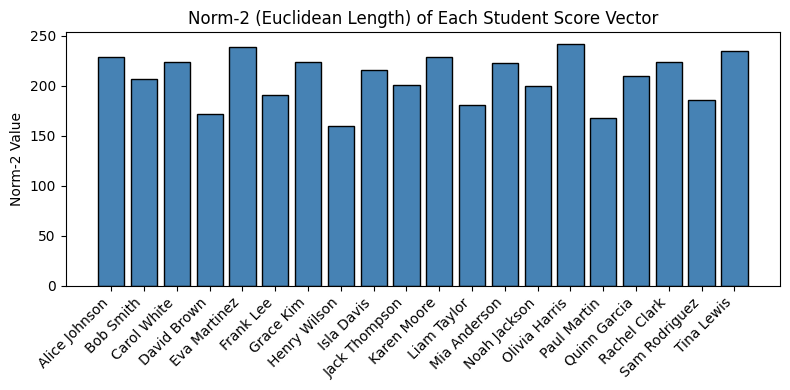

In [31]:
# Visualize Norm-2 (Overall Performance) for all students
plt.figure(figsize=(8, 4))
plt.bar(norm_df['Name'], norm_df['Norm-2'], color='steelblue', edgecolor='black')
plt.xticks(rotation=45, ha='right')
plt.title('Norm-2 (Euclidean Length) of Each Student Score Vector')
plt.ylabel('Norm-2 Value')
plt.tight_layout()
plt.show()

### 2b. Dot Product and Angle Between Two Students

- **Dot Product:** $\mathbf{a} \cdot \mathbf{b} = \sum a_i b_i$
- **Angle:** $\theta = \cos^{-1}\left(\frac{\mathbf{a} \cdot \mathbf{b}}{\|\mathbf{a}\| \|\mathbf{b}\|}\right)$

> A small angle (near 0°) means the two students have similar score patterns; a larger angle means they differ.

In [13]:
# Dot Product between Alice and Bob
dot_ab = np.dot(v_alice, v_bob)

# Angle between Alice and Bob
cos_theta = dot_ab / (np.linalg.norm(v_alice) * np.linalg.norm(v_bob))
cos_theta = np.clip(cos_theta, -1.0, 1.0)  # numerical safety
theta_rad = np.arccos(cos_theta)
theta_deg = np.degrees(theta_rad)

print('=== Alice vs Bob ===')
print(f'  Dot Product        : {dot_ab:.2f}')
print(f'  Cosine Similarity  : {cos_theta:.6f}')
print(f'  Angle (radians)    : {theta_rad:.6f}')
print(f'  Angle (degrees)    : {theta_deg:.4f}°')
print()

# Interpretation
if theta_deg < 10:
    print('Interpretation: Very similar performance patterns.')
elif theta_deg < 30:
    print('Interpretation: Moderately similar performance patterns.')
else:
    print('Interpretation: Quite different performance patterns.')

=== Alice vs Bob ===
  Dot Product        : 46869.00
  Cosine Similarity  : 0.989876
  Angle (radians)    : 0.142414
  Angle (degrees)    : 8.1597°

Interpretation: Very similar performance patterns.


In [14]:
# Compute pairwise angle matrix for first 5 students (for clarity)
names5 = list(student_vectors.keys())[:5]
vecs5  = np.array([student_vectors[n] for n in names5])

angle_matrix = np.zeros((5, 5))
for i in range(5):
    for j in range(5):
        cos_val = np.dot(vecs5[i], vecs5[j]) / (np.linalg.norm(vecs5[i]) * np.linalg.norm(vecs5[j]))
        cos_val = np.clip(cos_val, -1.0, 1.0)
        angle_matrix[i][j] = np.degrees(np.arccos(cos_val))

angle_df = pd.DataFrame(angle_matrix, index=names5, columns=names5)
print('Pairwise Angle Matrix (degrees) – First 5 Students:')
print(angle_df.round(2))

Pairwise Angle Matrix (degrees) – First 5 Students:
               Alice Johnson  Bob Smith  Carol White  David Brown  \
Alice Johnson           0.00       8.16         2.17        10.85   
Bob Smith               8.16       0.00         9.32         4.01   
Carol White             2.17       9.32         0.00        11.62   
David Brown            10.85       4.01        11.62         0.00   
Eva Martinez            2.01       8.76         2.30        11.48   

               Eva Martinez  
Alice Johnson          2.01  
Bob Smith              8.76  
Carol White            2.30  
David Brown           11.48  
Eva Martinez           0.00  


### 2c. Cross Product (3D – Selected Subjects)

Cross product is only defined for **3D vectors**. We select **Math, Physics, Chemistry** as our 3 subjects.

$$\mathbf{a} \times \mathbf{b} = \begin{vmatrix} \hat{i} & \hat{j} & \hat{k} \\ a_1 & a_2 & a_3 \\ b_1 & b_2 & b_3 \end{vmatrix}$$

In [15]:
# Select 3D sub-vectors: Math, Physics, Chemistry
subjects_3d = ['Math', 'Physics', 'Chemistry']

v_alice_3d = np.array(df[df['Name']=='Alice Johnson'][subjects_3d].values[0], dtype=float)
v_bob_3d   = np.array(df[df['Name']=='Bob Smith'][subjects_3d].values[0], dtype=float)

print('Alice 3D vector (Math, Physics, Chemistry):', v_alice_3d)
print('Bob   3D vector (Math, Physics, Chemistry):', v_bob_3d)

cross_ab = np.cross(v_alice_3d, v_bob_3d)
print('\nCross Product (Alice × Bob):', cross_ab)
print('Magnitude of Cross Product :', np.linalg.norm(cross_ab))
print()
print('Interpretation:')
print('  The cross product vector is perpendicular to both score vectors.')
print('  Its magnitude equals |Alice| × |Bob| × sin(θ), measuring the "area" spanned.')

Alice 3D vector (Math, Physics, Chemistry): [92. 88. 85.]
Bob   3D vector (Math, Physics, Chemistry): [78. 72. 68.]

Cross Product (Alice × Bob): [-136.  374. -240.]
Magnitude of Cross Product : 464.72787736480797

Interpretation:
  The cross product vector is perpendicular to both score vectors.
  Its magnitude equals |Alice| × |Bob| × sin(θ), measuring the "area" spanned.


---
## 3: Projection of One Vector onto Another

The **projection of vector $\mathbf{a}$ onto $\mathbf{b}$** gives the component of $\mathbf{a}$ that lies in the direction of $\mathbf{b}$:

$$\text{proj}_{\mathbf{b}} \mathbf{a} = \frac{\mathbf{a} \cdot \mathbf{b}}{\|\mathbf{b}\|^2} \mathbf{b}$$

The **scalar projection** (length of the shadow) is:

$$\text{scalar\_proj} = \frac{\mathbf{a} \cdot \mathbf{b}}{\|\mathbf{b}\|}$$

In [21]:
# Project Alice's vector onto Bob's vector
scalar_proj = np.dot(v_alice, v_bob) / np.linalg.norm(v_bob)
vector_proj = (np.dot(v_alice, v_bob) / np.dot(v_bob, v_bob)) * v_bob

print('Projecting Alice onto Bob (full 7D):')
print(f'  Scalar Projection     : {scalar_proj:.4f}')
print(f'  Vector Projection     : {vector_proj.round(4)}')
print()

# Verify: projection must lie along Bob's direction
# Check: vector_proj / v_bob = constant
ratio = vector_proj / v_bob
print(f'  Projection/Bob ratio  : {ratio.round(6)}  ← should be constant')

Projecting Alice onto Bob (full 7D):
  Scalar Projection     : 226.3226
  Vector Projection     : [85.2442 78.6869 74.3154 92.8943 87.4299 96.1729 81.9656]

  Projection/Bob ratio  : [1.092874 1.092874 1.092874 1.092874 1.092874 1.092874 1.092874]  ← should be constant


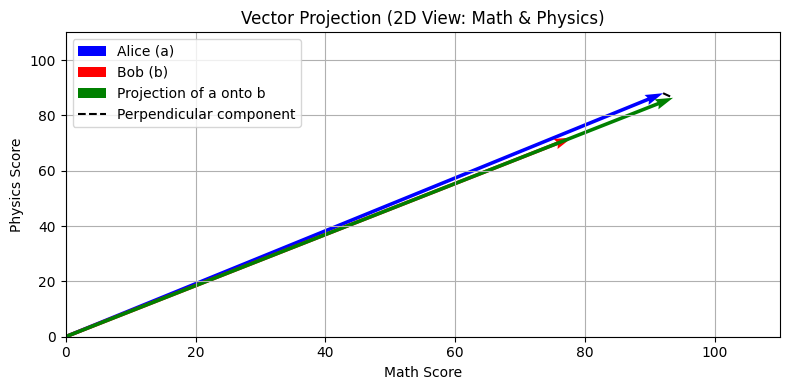

In [30]:
# Visualize projection in 2D (using Math & Physics scores for clarity)
a2d = v_alice[:2]  # Math, Physics
b2d = v_bob[:2]

proj2d = (np.dot(a2d, b2d) / np.dot(b2d, b2d)) * b2d

fig, ax = plt.subplots(figsize=(8, 4))
origin = np.array([0, 0])

ax.quiver(*origin, *a2d,   color='blue',   scale=1, scale_units='xy', angles='xy', width=0.005, label='Alice (a)')
ax.quiver(*origin, *b2d,   color='red',    scale=1, scale_units='xy', angles='xy', width=0.005, label='Bob (b)')
ax.quiver(*origin, *proj2d,color='green',  scale=1, scale_units='xy', angles='xy', width=0.005, label='Projection of a onto b')
ax.plot([a2d[0], proj2d[0]], [a2d[1], proj2d[1]], 'k--', lw=1.5, label='Perpendicular component')

ax.set_xlim(0, 110)
ax.set_ylim(0, 110)
ax.set_xlabel('Math Score')
ax.set_ylabel('Physics Score')
ax.set_title('Vector Projection (2D View: Math & Physics)')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

In [20]:
# Summary of all Part A results
print('='*55)
print('        PART A SUMMARY')
print('='*55)
print(f'Score Matrix Shape            : {score_matrix.shape}')
print(f'Alice Norm-1                  : {norm1_alice:.4f}')
print(f'Alice Norm-2                  : {norm2_alice:.4f}')
print(f'Bob   Norm-1                  : {norm1_bob:.4f}')
print(f'Bob   Norm-2                  : {norm2_bob:.4f}')
print(f'Dot Product (Alice · Bob)     : {dot_ab:.2f}')
print(f'Angle Between Alice & Bob     : {theta_deg:.4f}°')
print(f'Cross Product (3D) Alice × Bob: {cross_ab}')
print(f'Scalar Projection Alice→Bob   : {scalar_proj:.4f}')
print(f'Vector Projection Alice→Bob   : {vector_proj.round(2)}')
print('='*55)

        PART A SUMMARY
Score Matrix Shape            : (20, 7)
Alice Norm-1                  : 603.0000
Alice Norm-2                  : 228.6373
Bob   Norm-1                  : 546.0000
Bob   Norm-2                  : 207.0894
Dot Product (Alice · Bob)     : 46869.00
Angle Between Alice & Bob     : 8.1597°
Cross Product (3D) Alice × Bob: [-136.  374. -240.]
Scalar Projection Alice→Bob   : 226.3226
Vector Projection Alice→Bob   : [85.24 78.69 74.32 92.89 87.43 96.17 81.97]


---
## Part B: Matrix Operations

### 4. Transpose and Multiplication of the Score Matrix

In [23]:
# Extract numerical scores
subjects = ['Math', 'Physics', 'Chemistry', 'Biology', 'Computer_Science', 'English', 'Statistics']
A = df[subjects].values.astype(float)

print('Score Matrix A (shape:', A.shape, '):')
print(A)

# Transpose
A_T = A.T
print('\nTranspose A^T (shape:', A_T.shape, '):')
print(A_T)

# Matrix multiplication: A^T * A  (7x7 subject-subject correlation matrix)
ATA = A_T @ A
print('\nA^T × A (shape:', ATA.shape, '):')
print(np.round(ATA, 2))

Score Matrix A (shape: (20, 7) ):
[[92. 88. 85. 79. 95. 74. 90.]
 [78. 72. 68. 85. 80. 88. 75.]
 [85. 90. 88. 76. 92. 70. 88.]
 [60. 55. 62. 70. 65. 80. 58.]
 [95. 93. 91. 88. 97. 72. 94.]
 [70. 68. 74. 65. 72. 85. 69.]
 [88. 85. 80. 92. 84. 76. 86.]
 [55. 60. 58. 62. 50. 78. 55.]
 [82. 79. 83. 77. 88. 82. 80.]
 [74. 70. 66. 80. 76. 90. 72.]
 [91. 87. 89. 84. 93. 68. 91.]
 [65. 63. 70. 68. 60. 84. 64.]
 [87. 84. 82. 89. 86. 74. 85.]
 [73. 77. 75. 71. 78. 79. 74.]
 [96. 94. 92. 90. 98. 70. 95.]
 [58. 62. 60. 66. 55. 82. 57.]
 [80. 76. 78. 83. 82. 77. 79.]
 [89. 86. 84. 81. 90. 71. 88.]
 [67. 65. 69. 72. 64. 86. 66.]
 [93. 91. 90. 87. 96. 69. 92.]]

Transpose A^T (shape: (7, 20) ):
[[92. 78. 85. 60. 95. 70. 88. 55. 82. 74. 91. 65. 87. 73. 96. 58. 80. 89.
  67. 93.]
 [88. 72. 90. 55. 93. 68. 85. 60. 79. 70. 87. 63. 84. 77. 94. 62. 76. 86.
  65. 91.]
 [85. 68. 88. 62. 91. 74. 80. 58. 83. 66. 89. 70. 82. 75. 92. 60. 78. 84.
  69. 90.]
 [79. 85. 76. 70. 88. 65. 92. 62. 77. 80. 84. 68. 89. 71

## Part C: Linear Transformations & Geometry



## 5. Explain Line, Plane, and Hyperplane with respect to your dataset dimensions

- Line (1D): A single feature represents a line.
- Plane (2D): Two features create a 2D plane.
- Hyperplane (nD): Three or more features create higher-dimensional spaces where hyperplanes are used for separation.

Machine Learning algorithms such as SVM and Logistic Regression use hyperplanes for classification.


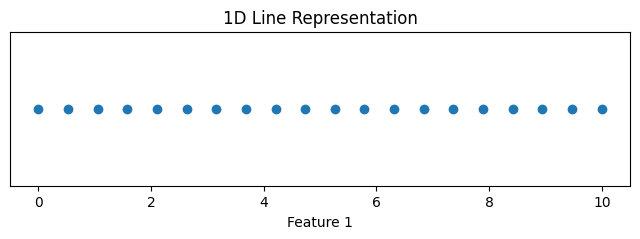

In [25]:
x = np.linspace(0,10,20)

plt.figure(figsize=(8,2))
plt.scatter(x, np.zeros_like(x))
plt.title("1D Line Representation")
plt.yticks([])
plt.xlabel("Feature 1")
plt.show()


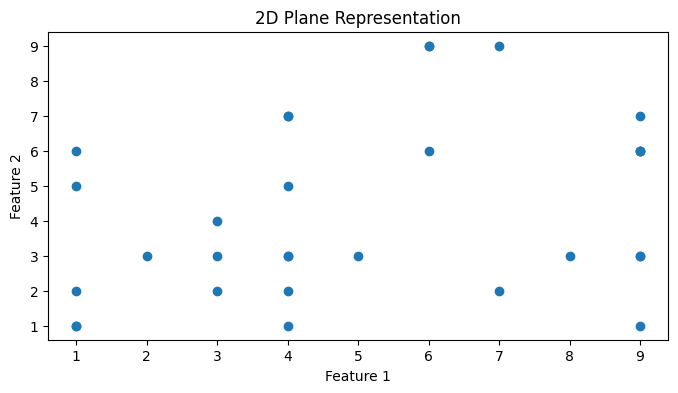

In [29]:
x = np.random.randint(1,10,30)
y = np.random.randint(1,10,30)

plt.figure(figsize=(8,4))
plt.scatter(x,y)
plt.title("2D Plane Representation")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()


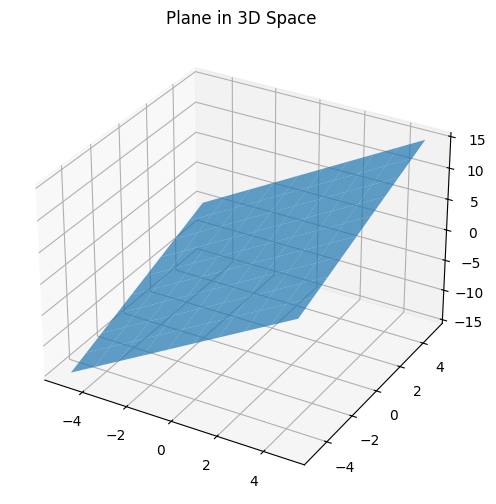

In [27]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

x = np.linspace(-5,5,10)
y = np.linspace(-5,5,10)

X,Y = np.meshgrid(x,y)
Z = 2*X + Y

ax.plot_surface(X,Y,Z,alpha=0.7)
ax.set_title("Plane in 3D Space")
plt.show()



## 6. Show how dimensionality increases from 2D → 3D → Higher Dimensions with Hyperplanes

| Features | Dimension |
|-----------|------------|
| 1 | 1D |
| 2 | 2D |
| 3 | 3D |
| n | nD |


In [32]:
dimensions = pd.DataFrame({
    'Number_of_Features':[1,2,3,4,5,10],
    'Dimension':[1,2,3,4,5,10]
})

dimensions


,Number_of_Features,Dimension
0,1,1
1,2,2
2,3,3
3,4,4
4,5,5
5,10,10


## Part D: Eigenvalues & Decomposition


### 7. Eigenvalues and Eigenvectors of the Covariance Matrix

Covariance Matrix:
[[168.73 153.03 132.97 102.71 186.37 -59.39 168.36]
 [153.03 148.51 126.05  86.88 169.36 -62.3  155.97]
 [132.97 126.05 117.96  69.74 149.78 -55.84 135.86]
 [102.71  86.88  69.74  83.57 108.36 -29.57  99.29]
 [186.37 169.36 149.78 108.36 216.68 -64.83 187.06]
 [-59.39 -62.3  -55.84 -29.57 -64.83  45.25 -62.97]
 [168.36 155.97 135.86  99.29 187.06 -62.97 169.67]]

Eigenvalues:
λ1 = 879.4909 (92.54% variance explained)
λ2 = 38.0611 (4.00% variance explained)
λ3 = 18.9367 (1.99% variance explained)
λ4 = 7.0123 (0.74% variance explained)
λ5 = 4.9710 (0.52% variance explained)
λ6 = 1.6594 (0.17% variance explained)
λ7 = 0.2370 (0.02% variance explained)

Eigenvectors:
                     PC1     PC2     PC3     PC4     PC5     PC6     PC7
Math             -0.4355  0.1584 -0.0125  0.1138  0.0777  0.6925 -0.5353
Physics          -0.4032 -0.1944  0.1180  0.5642 -0.5248 -0.3920 -0.1957
Chemistry        -0.3526 -0.3588 -0.1522  0.1399  0.7771 -0.3084 -0.0722
Biology          

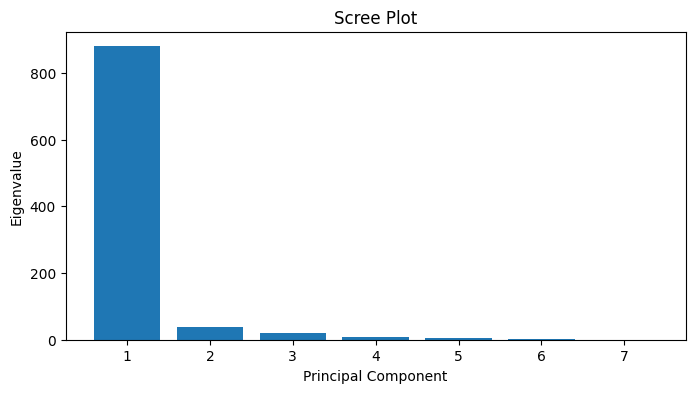

In [39]:
# Covariance Matrix
cov_matrix = np.cov(A, rowvar=False)

# Eigenvalues and Eigenvectors
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

print('Covariance Matrix:')
print(np.round(cov_matrix, 2))

print('\nEigenvalues:')
for i, ev in enumerate(eigenvalues):
    explained = ev / eigenvalues.sum() * 100
    print(f'λ{i+1} = {ev:.4f} ({explained:.2f}% variance explained)')

print('\nEigenvectors:')
ev_df = pd.DataFrame(
    eigenvectors,
    index=subjects,
    columns=[f'PC{i+1}' for i in range(len(subjects))]
)
print(np.round(ev_df, 4))

plt.figure(figsize=(8,4))
plt.bar(range(1, len(eigenvalues)+1), eigenvalues)
plt.xlabel('Principal Component')
plt.ylabel('Eigenvalue')
plt.title('Scree Plot')
plt.show()


### 8. LU Decomposition of the Dataset Matrix

In [34]:
# LU Decomposition requires a square matrix — use the 7×7 sub-matrix
A_sq = A[:7, :]   # 7 students × 7 subjects

P, L, U = lu(A_sq)

print('Original A (7×7 sub-matrix):')
print(np.round(A_sq, 2))

print('\nPermutation Matrix P:')
print(P.astype(int))

print('\nLower Triangular Matrix L:')
print(np.round(L, 4))

print('\nUpper Triangular Matrix U:')
print(np.round(U, 4))

# Verification: P @ A = L @ U
recon = P @ A_sq
LU   = L @ U
print('\nVerification — max absolute error between P·A and L·U:',
      np.round(np.max(np.abs(recon - LU)), 10))
print('Decomposition is correct ✔')

Original A (7×7 sub-matrix):
[[92. 88. 85. 79. 95. 74. 90.]
 [78. 72. 68. 85. 80. 88. 75.]
 [85. 90. 88. 76. 92. 70. 88.]
 [60. 55. 62. 70. 65. 80. 58.]
 [95. 93. 91. 88. 97. 72. 94.]
 [70. 68. 74. 65. 72. 85. 69.]
 [88. 85. 80. 92. 84. 76. 86.]]

Permutation Matrix P:
[[0 0 0 0 0 0 1]
 [0 0 0 0 1 0 0]
 [0 1 0 0 0 0 0]
 [0 0 1 0 0 0 0]
 [1 0 0 0 0 0 0]
 [0 0 0 0 0 1 0]
 [0 0 0 1 0 0 0]]

Lower Triangular Matrix L:
[[ 1.      0.      0.      0.      0.      0.      0.    ]
 [ 0.8947  1.      0.      0.      0.      0.      0.    ]
 [ 0.6316 -0.5504  1.      0.      0.      0.      0.    ]
 [ 0.9263 -0.169  -0.3907  1.      0.      0.      0.    ]
 [ 0.8211 -0.6419 -0.306   0.9917  1.      0.      0.    ]
 [ 0.7368 -0.0775  0.9153 -0.7882 -0.8647  1.      0.    ]
 [ 0.9684 -0.3039 -0.1383 -0.3495  0.3365  0.3915  1.    ]]

Upper Triangular Matrix U:
[[ 9.50000e+01  9.30000e+01  9.10000e+01  8.80000e+01  9.70000e+01
   7.20000e+01  9.40000e+01]
 [ 0.00000e+00  6.78950e+00  6.57890e+00 -2.

### 9. Singular Value Decomposition (SVD)

U Matrix Shape: (20, 7)
Singular Values:
[11.0416  3.371   2.1985  0.9366  0.8757  0.4619  0.1678]

Vt Matrix Shape: (7, 7)

Reconstruction Error: 0.0
σ1: 87.08% (Cumulative: 87.08%)
σ2: 8.12% (Cumulative: 95.20%)
σ3: 3.45% (Cumulative: 98.65%)
σ4: 0.63% (Cumulative: 99.28%)
σ5: 0.55% (Cumulative: 99.83%)
σ6: 0.15% (Cumulative: 99.98%)
σ7: 0.02% (Cumulative: 100.00%)


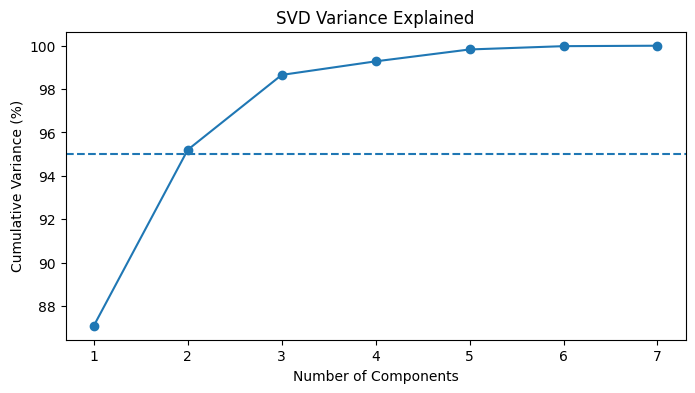

In [40]:
# Normalize matrix for SVD
scaler = StandardScaler()
A_normalized = scaler.fit_transform(A)

# Singular Value Decomposition
U_svd, S, Vt = svd(A_normalized, full_matrices=False)

print('U Matrix Shape:', U_svd.shape)
print('Singular Values:')
print(np.round(S,4))

print('\nVt Matrix Shape:', Vt.shape)

# Reconstruction
A_reconstructed = U_svd @ np.diag(S) @ Vt
error = np.linalg.norm(A_normalized - A_reconstructed)

print('\nReconstruction Error:', np.round(error,10))

explained_variance = (S**2)/np.sum(S**2)*100
cumulative_var = np.cumsum(explained_variance)

for i,(e,c) in enumerate(zip(explained_variance,cumulative_var)):
    print(f'σ{i+1}: {e:.2f}% (Cumulative: {c:.2f}%)')

plt.figure(figsize=(8,4))
plt.plot(range(1,len(S)+1), cumulative_var, marker='o')
plt.axhline(y=95, linestyle='--')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Variance (%)')
plt.title('SVD Variance Explained')
plt.show()


## Part E: Dimensionality Reduction

### 10. Principal Component Analysis (PCA) — Reduce to 2 Dimensions

PCA — Explained Variance Ratio:
  PC1: 87.08%
  PC2: 8.12%
  Total: 95.20%

PCA Component Loadings (contribution of each subject to PCs):
       Math  Physics  Chemistry  Biology  Computer_Science  English  \
PC1  0.4007   0.3978     0.3901   0.3400            0.3929  -0.3107   
PC2  0.1570  -0.0612    -0.1625   0.5565            0.1338   0.7831   

     Statistics  
PC1      0.4031  
PC2      0.0654  

2D Projection of Students (first 5 rows):
                  PC1     PC2
Name                         
Alice Johnson  2.0620 -0.2120
Bob Smith     -0.8650  1.7876
Carol White    1.9474 -1.0586
David Brown   -3.3689 -0.3758
Eva Martinez   3.1655  0.0698


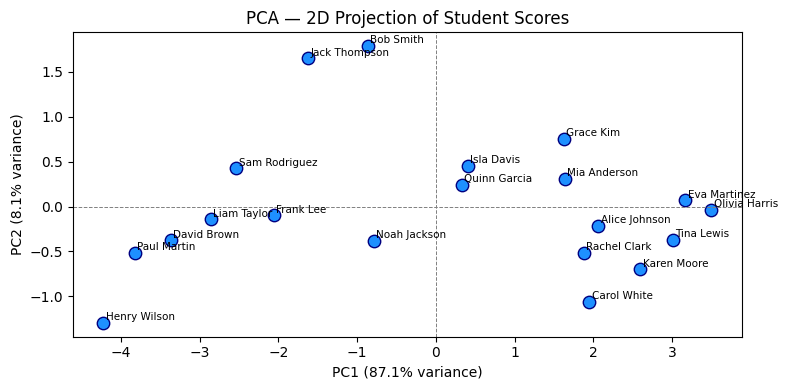

In [42]:
# Apply PCA
pca = PCA(n_components=2)
A_pca = pca.fit_transform(A_normalized)

print('PCA — Explained Variance Ratio:')
for i, v in enumerate(pca.explained_variance_ratio_):
    print(f'  PC{i+1}: {v*100:.2f}%')
print(f'  Total: {pca.explained_variance_ratio_.sum()*100:.2f}%')

print('\nPCA Component Loadings (contribution of each subject to PCs):')
loadings = pd.DataFrame(pca.components_, index=['PC1','PC2'], columns=subjects)
print(np.round(loadings, 4))

print('\n2D Projection of Students (first 5 rows):')
pca_df = pd.DataFrame(A_pca, columns=['PC1','PC2'], index=df['Name'])
print(np.round(pca_df.head(), 4))

# Plot
plt.figure(figsize=(8, 4))
plt.scatter(A_pca[:, 0], A_pca[:, 1], color='dodgerblue', edgecolors='navy', s=80)
for i, name in enumerate(df['Name']):
    plt.annotate(name, (A_pca[i, 0]+0.03, A_pca[i, 1]+0.03), fontsize=7.5)
plt.axhline(0, color='gray', lw=0.7, linestyle='--')
plt.axvline(0, color='gray', lw=0.7, linestyle='--')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title('PCA — 2D Projection of Student Scores')
plt.tight_layout()
plt.savefig('pca_2d.png', dpi=120)
plt.show()

### 11. Linear Discriminant Analysis (LDA) — Above vs Below Average

In [43]:
# Create target labels — Above Average / Below Average based on mean total score
df['Total']   = df[subjects].sum(axis=1)
threshold     = df['Total'].mean()
df['Category'] = df['Total'].apply(lambda x: 'Above Average' if x >= threshold else 'Below Average')

print(f'Score threshold (mean total): {threshold:.2f}')
print('\nCategory distribution:')
print(df['Category'].value_counts())
print()
print(df[['Name', 'Total', 'Category']].to_string(index=False))

# Apply LDA
y = df['Category'].values
lda = LinearDiscriminantAnalysis(n_components=1)
A_lda = lda.fit_transform(A_normalized, y)

print('\nLDA Coefficients (discriminant weights per subject):')
for s, coef in zip(subjects, lda.coef_[0]):
    print(f'  {s}: {coef:.4f}')

print('\nLDA Projection (discriminant score per student):')
lda_df = pd.DataFrame({'Name': df['Name'], 'LDA Score': A_lda.ravel(), 'Category': y})
print(lda_df.to_string(index=False))

Score threshold (mean total): 547.30

Category distribution:
Category
Above Average    11
Below Average     9
Name: count, dtype: int64

         Name  Total      Category
Alice Johnson    603 Above Average
    Bob Smith    546 Below Average
  Carol White    589 Above Average
  David Brown    450 Below Average
 Eva Martinez    630 Above Average
    Frank Lee    503 Below Average
    Grace Kim    591 Above Average
 Henry Wilson    418 Below Average
   Isla Davis    571 Above Average
Jack Thompson    528 Below Average
  Karen Moore    603 Above Average
  Liam Taylor    474 Below Average
 Mia Anderson    587 Above Average
 Noah Jackson    527 Below Average
Olivia Harris    635 Above Average
  Paul Martin    440 Below Average
 Quinn Garcia    555 Above Average
 Rachel Clark    589 Above Average
Sam Rodriguez    489 Below Average
   Tina Lewis    618 Above Average

LDA Coefficients (discriminant weights per subject):
  Math: -22.4085
  Physics: -3.8170
  Chemistry: -7.7539
  Biology: -2.650